# مشروع: Smart Assistant for Summarizing Arabic Texts

1. التثبيت.
2. الاستيرادات.
3. ربط Google Drive.
4. إعدادات المشروع.
5. تحميل البيانات.
6. تقسيم البيانات إلى train / validation / test.
7. preprocessing.
8. tokenization.
9. التدريب أو تحميل النموذج المحفوظ.
10. التقييم النهائي.
11. رسم loss.
12. رسم metrics.
13. التلخيص لنص عادي.
14. التلخيص للنصوص الطويلة بالـ chunking.
15. تلخيص PDF.
16. أمثلة اختبار متعددة.
17. واجهة Gradio.

## مقاييس التقييم المستخدمة

لأن التلخيص هنا **توليدي Abstractive / Generative**، لا نعتمد فقط على ROUGE.  
المقاييس المستخدمة هي:

1. ROUGE-1
2. ROUGE-2
3. ROUGE-L
4. BERTScore
5. METEOR
6. chrF
7. Semantic Similarity

## 1) تثبيت المكتبات

In [ ]:
# 1. تثبيت الإصدارات المستقرة (نحدد إصدار أقل من 5 لتجنب الـ Bug)
!pip install -q -U "transformers<5.0.0" datasets evaluate accelerate sentencepiece protobuf rouge_score bert-score sentence-transformers gradio pypdf sacrebleu nltk

# 2. إجبار البيئة على إعادة التشغيل لتفعيل المكتبات الجديدة في الذاكرة
import os
os.kill(os.getpid(), 9)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.0 MB/s eta 0:00:00
   ━━━

## 2) الاستيرادات

In [ ]:
import os
import re
import json
import math
import shutil
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    set_seed
)

import evaluate
import nltk

warnings.filterwarnings("ignore")

# تنزيل موارد METEOR
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## 3) ربط Google Drive

In [ ]:
# إذا كنت تعمل على Google Colab، سيتم ربط Google Drive لحفظ النموذج والنتائج
USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Google Drive mounted successfully.")
    except Exception as e:
        print("Google Drive لم يتم ربطه. سيتم الحفظ محليًا فقط.")
        print("Reason:", e)
        USE_GOOGLE_DRIVE = False

Google Drive لم يتم ربطه. سيتم الحفظ محليًا فقط.
Reason: mount failed


## 4) إعدادات المشروع

In [ ]:
class CFG:
    # النموذج العربي المستخدم
    MODEL_NAME = "UBC-NLP/AraT5v2-base-1024"

    # الداتا
    DATASET_NAME = "karimraouf/Arabic-Summarization-Dataset-AsDs"
    ARTICLE_COL = "article"
    SUMMARY_COL = "summary"

    # الأطوال
    MAX_INPUT_LENGTH = 1024
    MAX_TARGET_LENGTH = 128

    # التدريب
    SEED = 42
    NUM_EPOCHS = 3
    LEARNING_RATE = 5e-5
    TRAIN_BATCH_SIZE = 2
    EVAL_BATCH_SIZE = 2
    WEIGHT_DECAY = 0.01

    # التوليد
    NUM_BEAMS = 4
    MIN_SUMMARY_LENGTH = 20
    MAX_SUMMARY_LENGTH = 200
    LENGTH_PENALTY = 2.0
    NO_REPEAT_NGRAM_SIZE = 3

    # chunking للنصوص الطويلة
    CHUNK_TOKEN_SIZE = 850
    CHUNK_OVERLAP = 80
    MAX_HIERARCHICAL_ROUNDS = 3

    # للتحكم: إذا True يعيد التدريب حتى لو النموذج محفوظ
    FORCE_RETRAIN = False

    # عدد أمثلة الاختبار التي يتم توليدها وحفظها
    NUM_SHOWCASE_EXAMPLES = 5

    # موديل التشابه الدلالي
    SENTENCE_EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"


# مسارات الحفظ
if USE_GOOGLE_DRIVE:
    PROJECT_DIR = Path("/content/drive/MyDrive/arabic_summarization_project")
else:
    PROJECT_DIR = Path("./arabic_summarization_project")

MODEL_DIR = PROJECT_DIR / "saved_model"
RESULTS_DIR = PROJECT_DIR / "results"
PLOTS_DIR = PROJECT_DIR / "plots"
PREDICTIONS_DIR = PROJECT_DIR / "predictions"

for d in [PROJECT_DIR, MODEL_DIR, RESULTS_DIR, PLOTS_DIR, PREDICTIONS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Model directory:", MODEL_DIR)

Project directory: arabic_summarization_project
Model directory: arabic_summarization_project/saved_model


## 5) تحميل البيانات

In [ ]:
raw_dataset = load_dataset(CFG.DATASET_NAME)

print(raw_dataset)
print("\nExample:")
print(raw_dataset[list(raw_dataset.keys())[0]][0])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-0e6e9af3a88227(…):   0%|          | 0.00/3.47M [00:00<?, ?B/s]

data/validation-00000-of-00001-9eb13f38d(…):   0%|          | 0.00/441k [00:00<?, ?B/s]

data/test-00000-of-00001-bffbaf820797229(…):   0%|          | 0.00/441k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2075 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/259 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/260 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 2075
    })
    validation: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 259
    })
    test: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 260
    })
})

Example:
{'title': 'السريالية: رحلة إلى أعماق العقل الباطن والأحلام', 'article': "السريالية هي حركة ثقافية وفنية انطلقت في باريس في أوائل عشرينيات القرن الماضي، وكان الشاعر أندريه بريتون هو منظرها الرئيسي. تأثرت الحركة بشدة بنظريات سيغموند فرويد حول العقل الباطن والأحلام، وسعت إلى تحرير الفكر والخيال من قيود العقل والمنطق والعادات المجتمعية. الهدف كان الوصول إلى 'واقع فائق' (sur-reality) من خلال دمج عالم الأحلام وعالم اليقظة. استخدم الفنانون والكتاب السرياليون تقنيات مختلفة لإطلاق العنان لعقلهم الباطن. من أشهر هذه التقنيات 'الكتابة الآلية' (Automatism)، حيث يتم الكتابة أو الرسم بسرعة دون تفكير واعٍ. كما استخدموا تقنية تجميع الأشياء غير الم

## 6) تقسيم البيانات إلى Train / Validation / Test

In [ ]:
def prepare_dataset_splits(raw_dataset):
    """
    إذا كانت الداتا تحتوي train/validation/test نستخدمها كما هي.
    إذا كانت تحتوي train فقط نقسمها إلى 80/10/10.
    """
    keys = set(raw_dataset.keys())

    if {"train", "validation", "test"}.issubset(keys):
        print("الداتا تحتوي تقسيم جاهز: train / validation / test")
        return DatasetDict({
            "train": raw_dataset["train"],
            "validation": raw_dataset["validation"],
            "test": raw_dataset["test"],
        })

    if "train" in keys:
        print("الداتا تحتوي train فقط، سيتم التقسيم إلى 80/10/10.")
        dataset = raw_dataset["train"]

        split_1 = dataset.train_test_split(test_size=0.2, seed=CFG.SEED)
        train_dataset = split_1["train"]
        temp_dataset = split_1["test"]

        split_2 = temp_dataset.train_test_split(test_size=0.5, seed=CFG.SEED)
        validation_dataset = split_2["train"]
        test_dataset = split_2["test"]

        return DatasetDict({
            "train": train_dataset,
            "validation": validation_dataset,
            "test": test_dataset,
        })

    raise ValueError("لم أجد split مناسب في الداتا.")


dataset = prepare_dataset_splits(raw_dataset)

print(dataset)
print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))
print("Test size:", len(dataset["test"]))

الداتا تحتوي تقسيم جاهز: train / validation / test
DatasetDict({
    train: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 2075
    })
    validation: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 259
    })
    test: Dataset({
        features: ['title', 'article', 'summary', 'topic'],
        num_rows: 260
    })
})
Train size: 2075
Validation size: 259
Test size: 260


## 7) تحميل Tokenizer والنموذج الأساسي

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CFG.MODEL_NAME, use_fast=False)

# إذا كان النموذج محفوظًا ولم نطلب إعادة التدريب، سنحمّله لاحقًا من MODEL_DIR.
# أما هنا نجهز model إما من Drive أو من النموذج الأساسي.
model_exists = (MODEL_DIR / "config.json").exists()

if model_exists and not CFG.FORCE_RETRAIN:
    print("تم العثور على نموذج محفوظ. سيتم تحميله بدل إعادة التدريب.")
    model = AutoModelForSeq2SeqLM.from_pretrained(str(MODEL_DIR)).to(device)
else:
    print("لا يوجد نموذج محفوظ أو FORCE_RETRAIN=True. سيتم تحميل النموذج الأساسي للتدريب.")
    model = AutoModelForSeq2SeqLM.from_pretrained(CFG.MODEL_NAME).to(device)
# الحل لمشكلة IndexError: piece id is out of range
model.resize_token_embeddings(len(tokenizer))
print("Model loaded.")

لا يوجد نموذج محفوظ أو FORCE_RETRAIN=True. سيتم تحميل النموذج الأساسي للتدريب.
Model loaded.


## 8) preprocessing و tokenization

In [ ]:
def clean_arabic_text(text):
    """
    تنظيف بسيط للنص العربي بدون تخريب المعنى.
    """
    if text is None:
        return ""

    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.replace("\u200f", " ").replace("\u200e", " ")
    text = text.strip()
    return text


def preprocess_function(examples):
    articles = [clean_arabic_text(x) for x in examples[CFG.ARTICLE_COL]]
    summaries = [clean_arabic_text(x) for x in examples[CFG.SUMMARY_COL]]

    model_inputs = tokenizer(
        articles,
        max_length=CFG.MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        text_target=summaries,
        max_length=CFG.MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


remove_columns = dataset["train"].column_names

tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=remove_columns
)

tokenized_train = tokenized_dataset["train"]
tokenized_validation = tokenized_dataset["validation"]
tokenized_test = tokenized_dataset["test"]

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2075
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 259
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 260
    })
})


## 9) إعداد مقاييس ROUGE أثناء التدريب

In [ ]:
rouge_metric = evaluate.load("rouge")

def compute_rouge_metrics(eval_pred):
    """
    هذه الدالة تستخدم أثناء التدريب فقط حتى لا يصبح التدريب بطيئًا.
    المقاييس الثقيلة مثل BERTScore و Semantic Similarity سنحسبها في التقييم النهائي على test set.
    """
    preds, labels = eval_pred

    if isinstance(preds, tuple):
        preds = preds[0]

    # Filter out invalid token IDs from predictions before decoding.
    # Replace any token ID that is negative or >= tokenizer.vocab_size with tokenizer.pad_token_id.
    # This handles potential out-of-range IDs that can occur during generation.
    preds_filtered = np.where(
        (preds >= 0) & (preds < tokenizer.vocab_size),
        preds,
        tokenizer.pad_token_id
    )

    decoded_preds = tokenizer.batch_decode(preds_filtered, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=False
    )

    return {
        "rouge1": round(result["rouge1"] * 100, 4),
        "rouge2": round(result["rouge2"] * 100, 4),
        "rougeL": round(result["rougeL"] * 100, 4),
    }

## 10) التدريب أو تحميل النموذج المحفوظ

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

training_args = Seq2SeqTrainingArguments(
    output_dir=str(RESULTS_DIR / "checkpoints"),

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    learning_rate=CFG.LEARNING_RATE,
    per_device_train_batch_size=CFG.TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=CFG.EVAL_BATCH_SIZE,
    num_train_epochs=CFG.NUM_EPOCHS,
    weight_decay=CFG.WEIGHT_DECAY,

    predict_with_generate=True,
    generation_max_length=CFG.MAX_SUMMARY_LENGTH,
    generation_num_beams=CFG.NUM_BEAMS,

    fp16=torch.cuda.is_available(),
    report_to="none",

    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_rouge_metrics,
)

if model_exists and not CFG.FORCE_RETRAIN:
    print("تم تحميل النموذج المحفوظ. لن تتم إعادة التدريب.")
else:
    print("بدء التدريب...")
    train_result = trainer.train()

    print("حفظ النموذج النهائي...")
    trainer.save_model(str(MODEL_DIR))
    tokenizer.save_pretrained(str(MODEL_DIR))

    # حفظ معلومات التدريب
    train_metrics = train_result.metrics
    with open(RESULTS_DIR / "train_metrics.json", "w", encoding="utf-8") as f:
        json.dump(train_metrics, f, ensure_ascii=False, indent=2)

    print("تم حفظ النموذج في:", MODEL_DIR)

بدء التدريب...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,1.533600,1.682997,3.223900,1.378900,3.005100
2,2.009200,1.571905,5.199500,1.544400,5.000000
3,1.880200,1.545114,5.148000,1.158300,5.105100


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


حفظ النموذج النهائي...


## 11) تحميل نموذج الاستدلال النهائي

In [ ]:
# نستخدم model_inf و tokenizer_inf في جميع دوال التلخيص
tokenizer_inf = AutoTokenizer.from_pretrained(str(MODEL_DIR), use_fast=False)
model_inf = AutoModelForSeq2SeqLM.from_pretrained(str(MODEL_DIR)).to(device)
model_inf.eval()

print("Inference model loaded from:", MODEL_DIR)

## 12) رسم منحنيات Loss

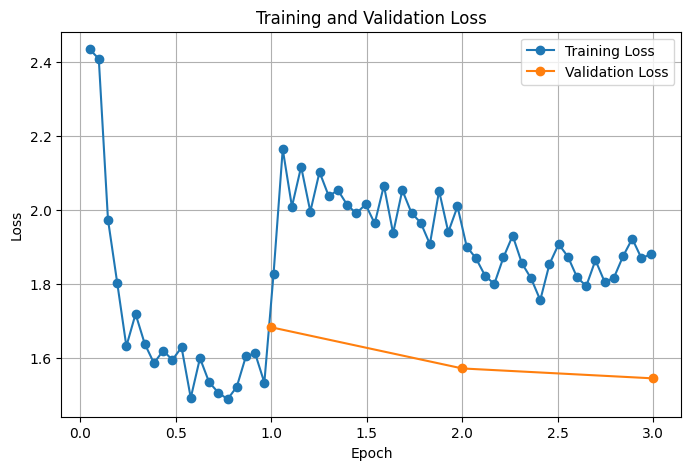

Loss plot path: arabic_summarization_project/plots/training_validation_loss.png


In [ ]:
def plot_training_curves(trainer, save_path=None):
    logs = trainer.state.log_history

    train_epochs, train_losses = [], []
    eval_epochs, eval_losses = [], []

    for log in logs:
        if "loss" in log and "epoch" in log:
            train_epochs.append(log["epoch"])
            train_losses.append(log["loss"])

        if "eval_loss" in log and "epoch" in log:
            eval_epochs.append(log["epoch"])
            eval_losses.append(log["eval_loss"])

    if len(train_losses) == 0 and len(eval_losses) == 0:
        print("لا توجد سجلات loss للرسم. ربما تم تحميل نموذج محفوظ بدون تدريب في هذه الجلسة.")
        return

    plt.figure(figsize=(8, 5))

    if train_losses:
        plt.plot(train_epochs, train_losses, marker="o", label="Training Loss")

    if eval_losses:
        plt.plot(eval_epochs, eval_losses, marker="o", label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


loss_plot_path = PLOTS_DIR / "training_validation_loss.png"
plot_training_curves(trainer, save_path=loss_plot_path)
print("Loss plot path:", loss_plot_path)

## 13) دالة تلخيص نص عادي

In [ ]:
@torch.no_grad()
def summarize_text(
    text,
    min_length=CFG.MIN_SUMMARY_LENGTH,
    max_length=CFG.MAX_SUMMARY_LENGTH,
    num_beams=CFG.NUM_BEAMS
):
    """
    تلخيص نص عربي عادي ضمن حد النموذج.
    """
    text = clean_arabic_text(text)

    if not text:
        return ""

    inputs = tokenizer_inf(
        text,
        return_tensors="pt",
        max_length=CFG.MAX_INPUT_LENGTH,
        truncation=True,
        padding=True
    ).to(device)

    summary_ids = model_inf.generate(
        **inputs,
        min_length=min_length,
        max_length=max_length,
        num_beams=num_beams,
        length_penalty=CFG.LENGTH_PENALTY,
        no_repeat_ngram_size=CFG.NO_REPEAT_NGRAM_SIZE,
        early_stopping=True
    )

    summary = tokenizer_inf.decode(
        summary_ids[0],
        skip_special_tokens=True
    )

    return summary.strip()

## 14) تلخيص النصوص الطويلة باستخدام Chunking

In [ ]:
def split_text_by_tokens(text, chunk_token_size=CFG.CHUNK_TOKEN_SIZE, overlap=CFG.CHUNK_OVERLAP):
    """
    تقسيم النص الطويل إلى chunks حسب عدد tokens.
    هذا أفضل من تقسيمه عشوائيًا بالكلمات لأن النموذج يعتمد على tokens.
    """
    text = clean_arabic_text(text)
    token_ids = tokenizer_inf.encode(text, add_special_tokens=False)

    if len(token_ids) <= chunk_token_size:
        return [text]

    chunks = []
    start = 0

    while start < len(token_ids):
        end = start + chunk_token_size
        chunk_ids = token_ids[start:end]
        chunk_text = tokenizer_inf.decode(chunk_ids, skip_special_tokens=True).strip()

        if chunk_text:
            chunks.append(chunk_text)

        if end >= len(token_ids):
            break

        start = max(0, end - overlap)

    return chunks


def summarize_long_text(text, max_rounds=CFG.MAX_HIERARCHICAL_ROUNDS):
    """
    تلخيص النص الطويل بطريقة hierarchical summarization:
    1. تقسيم النص إلى chunks.
    2. تلخيص كل chunk.
    3. دمج الملخصات.
    4. إذا الناتج ما زال طويلًا، نعيد التلخيص مرة ثانية.
    """
    text = clean_arabic_text(text)

    if not text:
        return ""

    chunks = split_text_by_tokens(text)

    if len(chunks) == 1:
        return summarize_text(chunks[0])

    partial_summaries = []
    for i, chunk in enumerate(chunks, start=1):
        print(f"تلخيص chunk {i}/{len(chunks)}")
        partial_summaries.append(summarize_text(chunk))

    combined_summary = " ".join(partial_summaries).strip()

    # إعادة تلخيص هرمي إذا كان الناتج طويلًا
    round_idx = 1
    while round_idx <= max_rounds:
        combined_token_len = len(tokenizer_inf.encode(combined_summary, add_special_tokens=False))

        if combined_token_len <= CFG.CHUNK_TOKEN_SIZE:
            return summarize_text(combined_summary)

        print(f"إعادة تلخيص هرمي - الجولة {round_idx}")
        chunks = split_text_by_tokens(combined_summary)
        partial_summaries = [summarize_text(chunk) for chunk in chunks]
        combined_summary = " ".join(partial_summaries).strip()

        round_idx += 1

    return combined_summary

## 15) تلخيص PDF

In [ ]:
from pypdf import PdfReader

def extract_text_from_pdf(pdf_path):
    """
    استخراج النص من PDF نصي.
    ملاحظة: إذا كان PDF عبارة عن صور scanned، سيحتاج OCR وهذا غير مضاف هنا.
    """
    reader = PdfReader(pdf_path)
    pages_text = []

    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            pages_text.append(page_text)

    full_text = "\n".join(pages_text)
    return clean_arabic_text(full_text)


def summarize_pdf(pdf_path):
    """
    تلخيص PDF كامل باستخدام نفس دالة تلخيص النصوص الطويلة.
    """
    pdf_text = extract_text_from_pdf(pdf_path)

    if not pdf_text:
        return "لم يتم استخراج نص من ملف PDF. قد يكون الملف ممسوحًا ضوئيًا scanned PDF."

    return summarize_long_text(pdf_text)

## 16) التقييم النهائي على Test Set بالمقاييس السبعة

In [ ]:
# تحميل المقاييس
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")
chrf_metric = evaluate.load("chrf")
bertscore_metric = evaluate.load("bertscore")


def generate_predictions(dataset_split, max_examples=None):
    """
    توليد ملخصات للنصوص الموجودة في split معين.
    """
    if max_examples is not None:
        dataset_split = dataset_split.select(range(min(max_examples, len(dataset_split))))

    sources = [clean_arabic_text(x) for x in dataset_split[CFG.ARTICLE_COL]]
    references = [clean_arabic_text(x) for x in dataset_split[CFG.SUMMARY_COL]]

    predictions = []

    for i, src in enumerate(sources, start=1):
        print(f"Generating summary {i}/{len(sources)}")
        predictions.append(summarize_text(src))

    return sources, predictions, references


def compute_semantic_similarity(predictions, references):
    """
    حساب Semantic Similarity باستخدام sentence-transformers.
    """
    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import cos_sim

    emb_model = SentenceTransformer(CFG.SENTENCE_EMBEDDING_MODEL)

    pred_emb = emb_model.encode(
        predictions,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True
    )

    ref_emb = emb_model.encode(
        references,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True
    )

    sims = cos_sim(pred_emb, ref_emb).diagonal()
    return float(sims.mean().cpu().item())


def compute_all_generation_metrics(sources, predictions, references):
    """
    المقاييس النهائية السبعة:
    1. ROUGE-1
    2. ROUGE-2
    3. ROUGE-L
    4. BERTScore
    5. METEOR
    6. chrF
    7. Semantic Similarity
    """
    rouge_result = rouge_metric.compute(
        predictions=predictions,
        references=references,
        use_stemmer=False
    )

    bertscore_result = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="ar",
        rescale_with_baseline=False
    )

    meteor_result = meteor_metric.compute(
        predictions=predictions,
        references=references
    )

    chrf_result = chrf_metric.compute(
        predictions=predictions,
        references=references
    )

    semantic_sim = compute_semantic_similarity(predictions, references)

    results = {
        "ROUGE-1": round(rouge_result["rouge1"] * 100, 4),
        "ROUGE-2": round(rouge_result["rouge2"] * 100, 4),
        "ROUGE-L": round(rouge_result["rougeL"] * 100, 4),
        "BERTScore": round(float(np.mean(bertscore_result["f1"])) * 100, 4),
        "METEOR": round(meteor_result["meteor"] * 100, 4),
        "chrF": round(chrf_result["score"], 4),
        "Semantic Similarity": round(semantic_sim * 100, 4),
    }

    return results

## 17) تشغيل التقييم النهائي وحفظ النتائج

In [ ]:
# ملاحظة:
# التقييم على كامل test set قد يستغرق وقتًا.
# إذا أردت اختبارًا سريعًا، ضع EVAL_MAX_EXAMPLES = 20 مثلًا.
# للتقييم النهائي الحقيقي، اجعلها None.

EVAL_MAX_EXAMPLES = 20

test_sources, test_predictions, test_references = generate_predictions(
    dataset["test"],
    max_examples=EVAL_MAX_EXAMPLES
)

final_metrics = compute_all_generation_metrics(
    test_sources,
    test_predictions,
    test_references
)

print("\nFinal Test Metrics:")
for k, v in final_metrics.items():
    print(f"{k}: {v}")

# حفظ المقاييس
metrics_path = RESULTS_DIR / "final_test_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, ensure_ascii=False, indent=2)

# حفظ التنبؤات
predictions_df = pd.DataFrame({
    "article": test_sources,
    "reference_summary": test_references,
    "generated_summary": test_predictions,
})

predictions_path = PREDICTIONS_DIR / "test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False, encoding="utf-8-sig")

print("\nSaved metrics to:", metrics_path)
print("Saved predictions to:", predictions_path)

## 18) رسم مقاييس التقييم

In [ ]:
def plot_metrics_bar(metrics_dict, save_path=None):
    names = list(metrics_dict.keys())
    values = list(metrics_dict.values())

    plt.figure(figsize=(10, 5))
    plt.bar(names, values)
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Score")
    plt.title("Final Evaluation Metrics on Test Set")
    plt.grid(axis="y")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


metrics_plot_path = PLOTS_DIR / "final_metrics_bar.png"
plot_metrics_bar(final_metrics, save_path=metrics_plot_path)
print("Metrics plot path:", metrics_plot_path)

## 19) أمثلة اختبار متعددة

In [ ]:
def evaluate_showcase_examples(num_examples=CFG.NUM_SHOWCASE_EXAMPLES):
    """
    توليد عدة أمثلة من test set وعرضها وحفظها.
    """
    sample = dataset["test"].select(range(min(num_examples, len(dataset["test"]))))

    rows = []
    for i, item in enumerate(sample, start=1):
        article = clean_arabic_text(item[CFG.ARTICLE_COL])
        reference = clean_arabic_text(item[CFG.SUMMARY_COL])
        generated = summarize_text(article)

        rows.append({
            "example_id": i,
            "article": article,
            "reference_summary": reference,
            "generated_summary": generated,
        })

        print("=" * 80)
        print(f"Example {i}")
        print("\nOriginal Article:")
        print(article[:1000] + ("..." if len(article) > 1000 else ""))
        print("\nReference Summary:")
        print(reference)
        print("\nGenerated Summary:")
        print(generated)

    df = pd.DataFrame(rows)
    path = PREDICTIONS_DIR / "showcase_examples.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("\nSaved showcase examples to:", path)

    return df


showcase_df = evaluate_showcase_examples()
showcase_df.head()

## 20) تجربة تلخيص نص عادي

In [ ]:
test_text = """
إن التكنولوجيا أصبحت جزءًا أساسيًا من حياة الإنسان المعاصر، حيث تدخل في التعليم والصحة والاتصالات والعمل.
وقد ساهمت التقنيات الحديثة في تسهيل الوصول إلى المعلومات وتطوير أساليب التعلم عن بعد، كما ساعدت في تحسين جودة الخدمات الطبية
من خلال أنظمة التشخيص الذكية وتخزين السجلات الصحية إلكترونيًا. ومع ذلك، فإن الاعتماد الكبير على التكنولوجيا يفرض تحديات جديدة
تتعلق بالخصوصية وأمن البيانات وتقليل التواصل المباشر بين الأفراد.
"""

summary = summarize_text(test_text)
print(summary)

## 21) تجربة تلخيص نص طويل

In [ ]:
long_text = test_text * 20

long_summary = summarize_long_text(long_text)
print(long_summary)

## 22) واجهة Gradio

In [ ]:
import gradio as gr

def gradio_summarize_text(text):
    if text is None or len(text.strip()) == 0:
        return "يرجى إدخال نص عربي."
    return summarize_long_text(text)


def gradio_summarize_pdf(file):
    if file is None:
        return "يرجى رفع ملف PDF."

    # Gradio قد يرجع مسار الملف مباشرة أو كائن فيه name
    pdf_path = file if isinstance(file, str) else file.name
    return summarize_pdf(pdf_path)


with gr.Blocks(title="Arabic Text Summarization Assistant") as demo:
    gr.Markdown("# Smart Assistant for Summarizing Arabic Texts")
    gr.Markdown("مساعد بسيط لتلخيص النصوص العربية وملفات PDF النصية باستخدام نموذج AraT5.")

    with gr.Tab("تلخيص نص"):
        text_input = gr.Textbox(
            label="أدخل النص العربي",
            lines=12,
            placeholder="اكتب أو الصق النص العربي هنا..."
        )
        text_button = gr.Button("تلخيص النص")
        text_output = gr.Textbox(label="الملخص", lines=8)

        text_button.click(
            fn=gradio_summarize_text,
            inputs=text_input,
            outputs=text_output
        )

    with gr.Tab("تلخيص PDF"):
        pdf_input = gr.File(
            label="ارفع ملف PDF نصي",
            file_types=[".pdf"]
        )
        pdf_button = gr.Button("تلخيص PDF")
        pdf_output = gr.Textbox(label="ملخص PDF", lines=10)

        pdf_button.click(
            fn=gradio_summarize_pdf,
            inputs=pdf_input,
            outputs=pdf_output
        )

# في Google Colab يفضل share=True للحصول على رابط خارجي
demo.launch(share=True)

## ملاحظات مهمة للمناقشة

- استخدمنا نموذج **AraT5v2-base-1024** لأنه نموذج عربي قائم على بنية T5 المناسبة للمهام التوليدية.
- تم تقسيم البيانات إلى **train / validation / test**.
- تم استخدام train للتدريب، و validation للمراقبة أثناء التدريب، و test للتقييم النهائي.
- لأن التلخيص توليدي، استخدمنا مقاييس لفظية ودلالية:
  - ROUGE-1
  - ROUGE-2
  - ROUGE-L
  - BERTScore
  - METEOR
  - chrF
  - Semantic Similarity
- تلخيص PDF يعمل مع ملفات PDF النصية، أما ملفات PDF المصورة scanned فتحتاج OCR.
- النصوص الطويلة لا يتم قصها فقط، بل يتم تقسيمها إلى chunks ثم تلخيصها بطريقة hierarchical.